In [1]:
library(ggplot2)
library(dplyr)

options(repr.plot.width=36/25.4,repr.plot.height=36/25.4,repr.plot.res=400)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# "indir" is a custom input path, and "outdir" is a custom output path.
indir = '../'
outdir = '../plots'

In [3]:
selected_loops=read.csv(paste0(indir,'/selected_loops.csv'))

In [4]:
dim(selected_loops);head(selected_loops)

[1] 33098     8

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA
,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>
1,463,504,chr1,463,ENSMUSG00000002459.17,-0.1732788,41,-0.1642807
2,641,685,chr1,641,ENSMUSG00000033740.17,0.1608042,44,-0.3793481
3,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.1875811,19,-0.1929578
4,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.2361129,26,-0.1172625
5,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.3663292,30,-0.0120595
6,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.3663292,42,-0.0120595


In [5]:
selected_loops$'loop_distance' = 10*selected_loops$'bin_distance'
head(selected_loops)

,bin_intergenic,bin_gene,chromosome,bin_intergenic_in_chromosome,gene_id,PCC_3C_RNA,bin_distance,PCC_5hmCG_RNA,loop_distance
,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<dbl>,<dbl>
1,463,504,chr1,463,ENSMUSG00000002459.17,-0.1732788,41,-0.1642807,410
2,641,685,chr1,641,ENSMUSG00000033740.17,0.1608042,44,-0.3793481,440
3,1024,1043,chr1,1024,ENSMUSG00000042501.12,-0.1875811,19,-0.1929578,190
4,1074,1048,chr1,1074,ENSMUSG00000042501.12,0.2361129,26,-0.1172625,260
5,1083,1113,chr1,1083,ENSMUSG00000048960.13,0.3663292,30,-0.0120595,300
6,1083,1125,chr1,1083,ENSMUSG00000048960.13,0.3663292,42,-0.0120595,420


In [6]:
library(RColorBrewer)
blues_pal <- brewer.pal(9, "Blues")
custom_blues <- blues_pal[5:9]

Warning message:
“The dot-dot notation (`..level..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(level)` instead.”


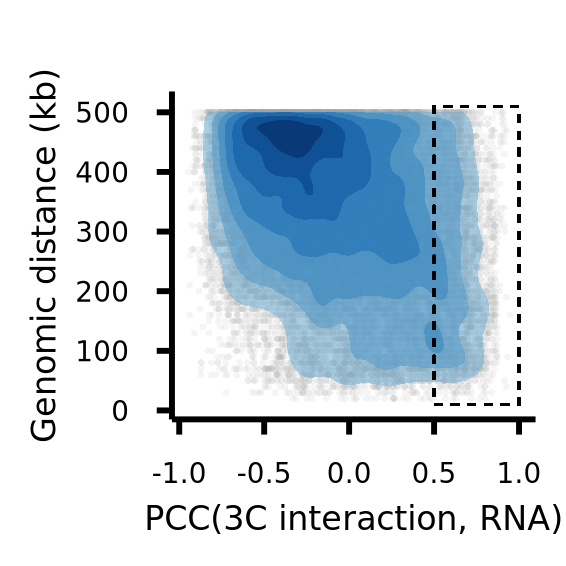

In [8]:
ggplot((selected_loops), aes(x = PCC_3C_RNA, y = loop_distance)) +
geom_point(color = "Gray 62", stroke=0, alpha=0.1, size = 0.85, shape='bullet') +
stat_density_2d(
    aes(fill = ..level.., alpha = ..level..),
    bins=8,
    geom = "polygon", 
    show.legend = FALSE
  ) +
  scale_fill_gradientn(colors = custom_blues)+
scale_alpha_continuous(range = c(0.5, 0.7)) + # Set alpha to transition from low (white) to high (blue)
geom_rect(xmin=0.5,xmax=1,ymin=10, ymax=510, fill = NA, color = "black", linetype = "22", linewidth=0.2)+
labs(title = "",
       x = "PCC(3C interaction, RNA)",
       y = "Genomic distance (kb)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) 

In [9]:
p <- ggplot((selected_loops), aes(x = PCC_3C_RNA, y = loop_distance)) +
geom_point(color = "Gray 62", stroke=0, alpha=0.1, size = 0.85, shape='bullet') +
stat_density_2d(
    aes(fill = ..level.., alpha = ..level..),
    bins=8,
    geom = "polygon", 
    show.legend = FALSE
  ) +
  scale_fill_gradientn(colors = custom_blues)+
scale_alpha_continuous(range = c(0.5, 0.7)) + # Set alpha to transition from low (white) to high (blue)
geom_rect(xmin=0.5,xmax=1,ymin=10, ymax=510, fill = NA, color = "black", linetype = "22", linewidth=0.2)+
labs(title = "",
       x = "PCC(3C interaction, RNA)",
       y = "Genomic distance (kb)") +
  theme_minimal() +
  theme(
    text = element_text(size = 5),
    axis.line.x = element_line(color = "black"),
    axis.line.y = element_line(color = "black"),
    axis.text = element_text(color = "black",family="ArialMT"),
    axis.title.x = element_text(color="black", size=6,family="ArialMT"),
    axis.title.y = element_text(color="black", size=6,family="ArialMT"),
    axis.text.x = element_text(color="black", size=5,family="ArialMT", hjust = 0.5,),
    axis.text.y = element_text(color="black", size=5,family="ArialMT"),
    axis.ticks = element_line(color = "black"),
    strip.text = element_text(color = "black",family="ArialMT"),
    plot.title = element_text(hjust = 0.5, color = "black",family="ArialMT"),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  ) 

pdf(paste0(outdir, '/04_scatterplot_PCC(3C,RNA)_distance.pdf'), width=36/25.4,height=36/25.4, family="ArialMT")
print(p)
dev.off()

agg_record_654950693 
                   2